# How to Train a Neural Network to Detect Fraudulent Credit Card Transactions

## Abstract

Credit card fraud detection faces extreme class imbalance, posing a challenge when using artificial intelligence to classify new transactions. This tutorial compares three PyTorch-based neural network approaches: standard Binary Cross-Entropy, weighted BCE, and Focal Loss. Experiments across differing architectures (16–128 hidden nodes) reveal that loss function design is critical. Unweighted BCE collapses entirely at small architectures, while weighted and focal approaches remain effective at all sizes. These findings demonstrate that appropriate loss design matters more than model capacity for imbalanced fraud detection.

## Learning Objectives

By completing this tutorial, you will:
- Understand how class imbalance affects neural network training
- Implement three different loss functions in PyTorch for fraud detection
- Compare Binary Cross-Entropy, weighted BCE, and Focal Loss approaches
- Analyse the impact of network architecture on model performance
- Evaluate models using precision, recall, and F1 score for imbalanced datasets
- Interpret confusion matrices in the context of fraud detection costs

## Table of Contents

1. Abstract
2. Learning Objectives
3. Imports
4. Data Loading and Exploration
5. Pre-processing
6. Neural Network Model
   - Training Step — Batch Processing
   - Training Function
   - Unified Neural Network Class
   - Evaluation Function
7. Config 1: Binary Cross-Entropy Loss (Unweighted)
   - Config 1 Model Evaluation
8. Config 2: BCEWithLogitsLoss
   - Config 2 Model Evaluation
9. Config 3: Focal Loss
10. Model Evaluation
    - Configuration Hyperparameters
    - Full Results
    - Evaluation Visualisations
    - Comparison with Similar Tutorials
11. References

## Imports

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.container import BarContainer
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_theme(style="white", context="notebook", font_scale=1.1)

## Data Loading and Exploration

First we will import and explore the dataset. Make sure the dataset is downloaded and named `credit_card_transactions.csv` within the `/data` directory.

The dataset is a collection of European credit card transactions from September 2013, made available by the ULB Machine Learning Group [1].

Importing the data using Pandas will give us a Pandas DataFrame, which is the industry standard Python library for data analysis and manipulation.

Once imported, we can inspect the following characteristics of the data:
- How many transactions are classified as fraudulent?
- How many are non-fraudulent?
- What's the proportion of fraudulent transactions?

In [28]:
df = pd.read_csv("./data/credit_card_transactions.csv")

num_of_non_fraudulent_transactions = len(df[df["Class"] == 0])
num_of_fraudulent_transactions = len(df[df["Class"] == 1])
percentage_of_fraudulent_transactions = num_of_fraudulent_transactions / len(df) * 100

print("Null values in dataset:", df.isnull().values.any())
print("Total transactions:", len(df))
print("Number of non-fraudulent transactions:", num_of_non_fraudulent_transactions)
print("Number of fraudulent transactions:", num_of_fraudulent_transactions)
print("Percentage of fraudulent transactions:", percentage_of_fraudulent_transactions)

Null values in dataset: False
Total transactions: 284807
Number of non-fraudulent transactions: 284315
Number of fraudulent transactions: 492
Percentage of fraudulent transactions: 0.1727485630620034


It becomes clear that the data is highly imbalanced, with only 492/284807 (0.17%) transactions being fraudulent.

This will become a challenge later when we try to train a model, as the model has so few fraudulent transactions to make decisions with.

It is worth also inspecting the columns and values of the data, which can be done with the following commands:

In [29]:
# Display first 5 rows to inspect column names, feature ranges and data types
print(df.head())

# Display a statistics table to inspect the ranges and various other data metrics
print(df.describe())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Features V1-V28 are already centred around zero as a result of PCA transformation, but are not bounded to any fixed range.

Amount retains its original scale and has a much larger magnitude, so we standardise it later to prevent it from dominating the model.

The final column is our target or label and informs us whether a transaction is legitimate (0) or fraudulent (1).

We can visually display the class imbalance with a bar chart, where the bar for fraudulent transactions is almost unnoticeable:

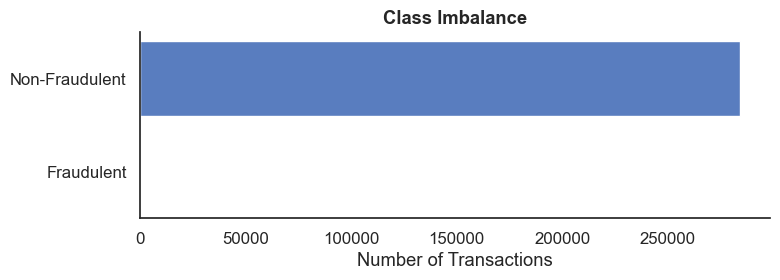

In [30]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.barplot(
    x=[num_of_non_fraudulent_transactions, num_of_fraudulent_transactions],
    y=["Non-Fraudulent", "Fraudulent"],
    hue=["Non-Fraudulent", "Fraudulent"],
    palette="muted", legend=False, ax=ax, orient='h'
)
ax.set_title('Class Imbalance', fontweight='bold')
ax.set_xlabel('Number of Transactions')
ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

Another visualisation we can make on the data is the amount distribution, showing that for non-fraudulent transactions, the vast majority are small transactions but range up to over 25000 USD.

Fraudulent transactions don't reach quite the same amount, and stay under around 2000 USD with the vast majority being small transactions under 500 USD

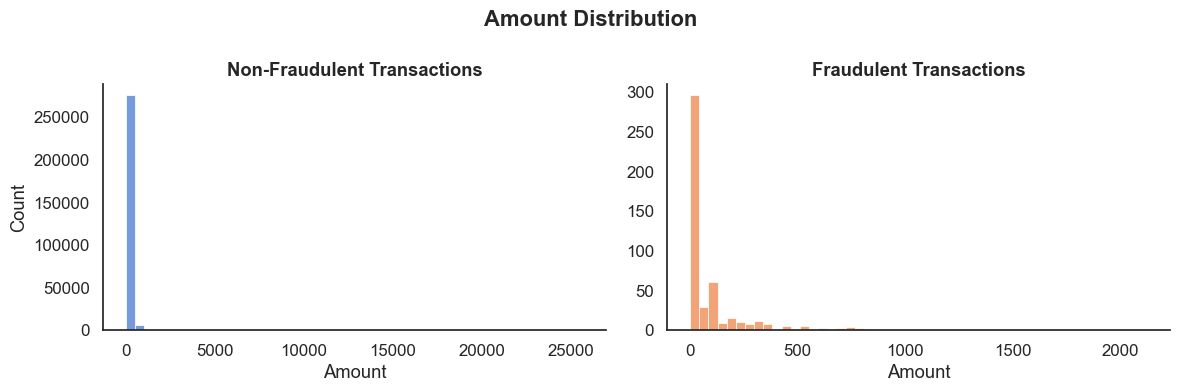

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
palette = sns.color_palette("muted")

sns.histplot(df[df["Class"] == 0].Amount, ax=ax1, color=palette[0], bins=50)
ax1.set_title("Non-Fraudulent Transactions", fontweight='bold')
ax1.set_xlabel("Amount")
ax1.set_ylabel("Count")

sns.histplot(df[df["Class"] == 1].Amount, ax=ax2, color=palette[1], bins=50)
ax2.set_title("Fraudulent Transactions", fontweight='bold')
ax2.set_xlabel("Amount")
ax2.set_ylabel("")

fig.suptitle("Amount Distribution", fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

## Pre-processing

Now the data must be processed in a way that converts it into data types that we can use to train a model with.

Firstly, it is necessary that we split the data initially into a set of features and labels. Features contain the data points that identify a transaction, while labels contain the classification of those transactions. In this case, we only have a single label which is the class.

Time is irrelevant, as this only refers to the time elapsed since the transactions were tracked, and shouldn't have any effect on the result.

In [32]:
features = df.drop(["Class", "Time"], axis=1)
label = df["Class"]

Next, we can utilise the `train_test_split` function from scikit-learn, which will randomly split the data into train and test sets.

Balancing the amount of data in the training set and testing set is essential. It's important to ensure training data is sufficient, while ensuring the test set has enough data to be meaningful. In this case, we use 1/3 for testing and 2/3 for training. Using a standard 80/20 split would result in only 98 fraud cases for evaluation, while this approach contains a sufficient number of 162, helping to produce more reliable metrics.

We can also make use of the `stratify` parameter, which will roughly keep the proportion of labels in both training and test sets [2].

In [33]:
x_train, x_test, y_train, y_test = train_test_split(features, label, test_size=0.33, random_state=42, stratify=label)

Earlier we identified that most features were PCA transformed, but we still need to scale amount. We can do this by using sklearn's StandardScaler.

In [34]:
scaler = StandardScaler()
x_train[['Amount']] = scaler.fit_transform(x_train[['Amount']])
x_test[['Amount']] = scaler.transform(x_test[['Amount']])

A benefit of PyTorch is that it is built to utilise GPU cores if available. The below code will find the best available device on the machine so we can convert Tensors onto that device. [MPS](https://developer.apple.com/metal/pytorch/) (Metal Performance Shaders) is used for Apple Silicon, while [CUDA](https://developer.nvidia.com/cuda) is NVIDIA's platform for General Purpose Computing on GPUs. For detail on PyTorch's device selection API, see the [PyTorch documentation](https://docs.pytorch.org/docs/stable/generated/torch.cuda.device.html).

In [35]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


As we are using PyTorch, we will convert the dataframe into PyTorch objects. PyTorch uses a data type called Tensors, which is similar to an array or a matrix. We will also ensure that the tensors are moved onto the GPU if available.

In [36]:
X_train_tensor = torch.tensor(x_train.values).float().to(device)
X_test_tensor = torch.tensor(x_test.values).float().to(device)
y_train_tensor = torch.tensor(y_train.values).float().to(device)
y_test_tensor = torch.tensor(y_test.values).float().to(device)

Next we must determine an optimal batch size for training. Each epoch will have batches of 4096 and update the weights after each of ~47 batches.

Using a higher batch size will make use of parallel processing and improve the time it takes to train a model, while batches too high could exceed memory constraints [3].

A higher batch size makes sense for this use case due to the class imbalance. On average, each batch will contain 1 or 2 fraudulent payments, while using a lower batch size, say 128, will most often not contain any fraudulent payments.

In [37]:
batch_size = 4096

Next, we need to prepare the tensors for efficient processing.

`TensorDataset` essentially zips together the features and the labels by matching indices so that they are synchronised when batching [4].

`DataLoader` makes batching and shuffling easy when training, automatically batching the data from the tensors so memory can be used effectively [4].

In [38]:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
validation_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_data_loader = torch.utils.data.DataLoader(train_dataset, batch_size)
validation_data_loader = torch.utils.data.DataLoader(validation_dataset, batch_size)

## Neural Network Model

### Training Step - Batch Processing

This function is used across all three configurations. It is adapted from source [5].

During the forward pass, the model uses the input batch to produce predictions, and the loss is computed with the true labels.

If an optimiser is provided, the function is in training mode updating weights; otherwise the function is in validation mode computing loss without updating weights.

Returning the loss value and batch size means we can calculate a weighted average loss across batches.

In [39]:
# Batch processing function adapted from source [5]
def batch_processing(model, loss_function, x_batch, y_batch, optimiser=None):
    # Forward pass
    loss = loss_function(model(x_batch), y_batch.view(-1, 1))

    # If optimiser provided, we're training (not validating)
    if optimiser is not None:
        loss.backward() # Compute gradients with backpropagation
        optimiser.step() # Update weights using gradients
        optimiser.zero_grad()

    return loss.item(), len(x_batch)
### end of source [5]

#source [5] https://www.kaggle.com/code/rinabuoy/credit-card-fraud-detection-with-pytorch

### Training Function

Now for the main training loop, adapted from source [5]. It iterates over a fixed number of epochs (training cycles), processing batches of training data per epoch with our `batch_processing` function defined above.

Then we set the model to validation mode and disable gradient computation to reduce computation when computing validation loss.

Finally, we compute the weighted average loss for each epoch and print it to monitor how loss changes over training.

In [40]:
# Training loop adapted from source [5]
def train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader):
    val_losses = []
    for epoch in range(epochs):
        # Set model to training mode
        model.train()

        # Process batches using vectorised operations
        for x_batch, y_batch in train_data_loader:
            # Compute loss, compute gradients, update weights, clear gradients
            batch_processing(model, loss_function, x_batch, y_batch, optimiser)

        # Validation phase
        model.eval()

        # Disable gradient computation to reduce computation
        with torch.no_grad():
            losses, nums = zip(
                *[batch_processing(model, loss_function, xb, yb) for xb, yb in validation_data_loader]
            )

        # Compute weighted average loss across all validation batches
        val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)
        print(epoch, val_loss)
        val_losses.append(val_loss)

    return val_losses
### end of source [5]

#source [5] https://www.kaggle.com/code/rinabuoy/credit-card-fraud-detection-with-pytorch

### Unified Neural Network Class

Firstly, we define the neural network with a parameterised `input_dimension` and `hidden_layer_size`, as this class is reused across all three configurations. The structure follows the pattern in [6].

We also add a `use_sigmoid` parameter:
- `use_sigmoid=True` for Config 1 (BCELoss requires sigmoid output)
- `use_sigmoid=False` for Config 2 & 3 (BCEWithLogitsLoss and FocalLoss apply sigmoid internally)

`Sequential` chains layers together — the output of one becomes the input of the next.

`ReLU` introduces non-linearity, allowing the model to learn complex patterns from the data.

In [ ]:
# Network structure inspired by source [6]
class NeuralNetwork(nn.Module):
    def __init__(self, input_dimension, hidden_layer_size, use_sigmoid=False):
        # Calls the parent class (nn.Module) constructor registering model with PyTorch's module system so it can track parameters, gradients, and device placement
        super().__init__()
        layers: list[nn.Module] = [
            nn.Linear(input_dimension, hidden_layer_size),
            nn.ReLU(),
            nn.Linear(hidden_layer_size, hidden_layer_size),
            nn.ReLU(),
            nn.Linear(hidden_layer_size, 1),
        ]
        if use_sigmoid:
            layers.append(nn.Sigmoid())

        self.linear_relu_stack = nn.Sequential(*layers)

    def forward(self, x):
        return self.linear_relu_stack(x)
### end of source [6]

#source [6] https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

### Evaluation Function

The below function will be used to evaluate and print metrics about a model, by taking the state of the model after training and applying it to the validation data.

We utilise the scikit-learn metrics module to return Accuracy, Precision, Recall, F1 score, and a Confusion Matrix [7].

- **Accuracy**: Out of all the predictions we made, how many were correct?
- **Precision**: Out of all the positive predictions we made, how many were true?
- **Recall**: Out of all the data points that should be predicted as positive, how many did we correctly identify?
- **F1 Score**: A measure that combines recall and precision.
- **Confusion Matrix**: A matrix showing the number of true positives, false positives, true negatives, and false negatives.

It is worth noting that all configs will show significantly high accuracy (>99%), simply due to the large number of non-fraudulent payments. Hence accuracy is an unreliable metric given the extreme class imbalance, and metrics like recall and F1 score are more valuable for parameter tuning and config selection.

In [42]:
def evaluate_model(model, data_loader, threshold=0.5, apply_sigmoid=True):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in data_loader:
            logits = model(xb)
            probs = torch.sigmoid(logits) if apply_sigmoid else logits
            preds = (probs > threshold).float()

            all_predictions.extend(preds.cpu().numpy().flatten())
            all_labels.extend(yb.cpu().numpy().flatten())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    cm = confusion_matrix(all_labels, all_predictions)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'y_pred': all_predictions,
    }

def print_evaluation(config_name, metrics):
    print(f"\n{'='*50}")
    print(f"{config_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1 Score:  {metrics['f1']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Non-Fraud  Fraud")
    print(f"Actual Non-Fraud {metrics['confusion_matrix'][0][0]:>6}    {metrics['confusion_matrix'][0][1]:>6}")
    print(f"Actual Fraud     {metrics['confusion_matrix'][1][0]:>6}    {metrics['confusion_matrix'][1][1]:>6}")
    print(f"{'='*50}\n")

## Config 1: Binary Cross-Entropy Loss (Unweighted)

The first configuration is simple and treats all examples equally. With 99.8% non-fraud, the model will likely optimise for non-fraud and ignore rare frauds.

The formula for the BCE function is as follows [8]:

```
BCE = -[y·log(p) + (1-y)·log(1-p)]
```

The steps from the below code block show:
- Define the number of epochs (training cycles)
- Instantiate the Neural Network
- Create an Adam optimiser, which automatically adjusts learning rates and updates weights to minimise loss [9]
- Define our loss function (BCELoss)
- Call the training function

In [43]:
epochs = 40 # tested various values and >40 leads to overtraining, hence stopping early
hidden_layer_size = 64 # optimal hidden layer size for this configuration
torch.manual_seed(42) # a seed means weights are initialised the same therefore making results repeatable
model = NeuralNetwork(X_train_tensor.shape[1], hidden_layer_size, use_sigmoid=True).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.BCELoss()
losses1 = train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader)

0 0.042962266329683405
1 0.009561858810319523
2 0.005836584291932373
3 0.004691552679775848
4 0.004201074503287366
5 0.003912720465437387
6 0.0037281121082030455
7 0.0036088650645603056
8 0.003526835904826491
9 0.003466074690591159
10 0.003421652732088978
11 0.0033863528727581917
12 0.003359840163332105
13 0.0033381808637153202
14 0.0033180999890806864
15 0.003300501403204703
16 0.003283635568576982
17 0.003266553099033123
18 0.0032513515297406307
19 0.003236712669262131
20 0.0032222541655693372
21 0.0032104868441758215
22 0.0032002012553288424
23 0.0031877094671173166
24 0.0031712945514653307
25 0.0031528721882723466
26 0.003133310612759063
27 0.0031096171542037243
28 0.0030947465717898973
29 0.003078823297751721
30 0.0030665755763699377
31 0.0030413182672028387
32 0.003028103925248741
33 0.0030112856045981557
34 0.0030018619723094814
35 0.0029884953710715696
36 0.0029770609357489494
37 0.002970610264024001
38 0.002971040248553517
39 0.0029645356153808152


### Config 1 Model Evaluation

In [44]:
model_config1 = model
metrics1 = evaluate_model(model_config1, validation_data_loader, apply_sigmoid=False)
print_evaluation("Config 1: BCELoss (Unweighted)", metrics1)


Config 1: BCELoss (Unweighted)
Accuracy:  0.9994
Precision: 0.8929
Recall:    0.7716
F1 Score:  0.8278

Confusion Matrix:
                 Predicted
                 Non-Fraud  Fraud
Actual Non-Fraud  93810        15
Actual Fraud         37       125



## Config 2: BCEWithLogitsLoss

The second configuration uses weights on the fraud samples to improve their significance during training. In this case, we multiply fraud samples' loss by a weight of 10.

The formula for the weighted BCE function is as follows [10]:

```
Weighted BCE = pos_weight · y · log(p) + (1-y) · log(1-p)
```

The steps from the below code block show:
- Define the number of epochs (training cycles)
- Instantiate the Neural Network
- Create an Adam optimiser [9]
- Define our loss function (BCEWithLogitsLoss) and pass in the class weighting
- Call the training function
- Save the configuration for later evaluation

In [45]:
epochs = 100 # loss continues to drop over more epochs so no need to terminate early
hidden_layer_size = 128 # optimal hidden layer size for this configuration
torch.manual_seed(42) # a seed means weights are initialised the same therefore making results repeatable
model = NeuralNetwork(X_train_tensor.shape[1], hidden_layer_size, use_sigmoid=False).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=0.0001) # most effective learning rate for this configuration
pos_weight = torch.tensor([10.0]).to(device)
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
losses2 = train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader)

0 0.5330752855341014
1 0.3663970057103134
2 0.23183540923930504
3 0.14560540623713408
4 0.09800422968339353
5 0.07144047785765383
6 0.05582939773916581
7 0.046034615429070655
8 0.03943473823888656
9 0.034756930901619215
10 0.03149718087693432
11 0.029180658304177598
12 0.02741877699741584
13 0.02601660308135841
14 0.024871937073192855
15 0.023931640087323926
16 0.023162399867621537
17 0.022534592360723353
18 0.02201751937903894
19 0.021587286043759535
20 0.02122452072004301
21 0.020915937512287083
22 0.020652099141294435
23 0.02042558286955685
24 0.02022902679668953
25 0.020056039259157644
26 0.01990378502654512
27 0.019770009629216333
28 0.01964965702618583
29 0.019543946906167196
30 0.019447906710923016
31 0.019361116631946625
32 0.019283665821785183
33 0.019211350719656697
34 0.019145929877098268
35 0.019085965899893222
36 0.019030122443052546
37 0.018978095516811656
38 0.01893086607106412
39 0.018886273183477603
40 0.018845279126784586
41 0.018808299905454153
42 0.01877072809301876

### Config 2 Model Evaluation

In [46]:
model_config2 = model
metrics2 = evaluate_model(model_config2, validation_data_loader, apply_sigmoid=True)
print_evaluation("Config 2: BCEWithLogitsLoss", metrics2)


Config 2: BCEWithLogitsLoss
Accuracy:  0.9991
Precision: 0.6907
Recall:    0.8272
F1 Score:  0.7528

Confusion Matrix:
                 Predicted
                 Non-Fraud  Fraud
Actual Non-Fraud  93765        60
Actual Fraud         28       134



## Config 3: Focal Loss

The final configuration is similar to BCEWithLogitsLoss, but instead of increasing the weights on the fraudulent data points, we reduce the weights of the non-fraudulent transactions. Designed for extreme class imbalance, Focal Loss dynamically down-weights examples that are easily classified, forcing the model to focus on the more sparse, challenging ones [11].

The `(1-pt)^γ` term is the key factor. When a sample is correctly classified with high confidence, `pt` is high, so the loss contribution shrinks, directing the model's attention to harder examples.

There are two parameters:
  - `α=0.25`: an overall scaling factor that prevents the loss from being too large or too small
  - `γ=2`: focusing strength — higher γ means more focus on difficult examples

In [47]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        return focal_loss.mean()

Similarly to the other configurations, we then train the model with custom parameters.

In [48]:
epochs = 25 # severely overfits beyond 30 epochs, hence an early termination
hidden_layer_size = 128 # optimal hidden layer size for this configuration
torch.manual_seed(42) # a seed means weights are initialised the same therefore making results repeatable
model = NeuralNetwork(X_train_tensor.shape[1], hidden_layer_size, use_sigmoid=False).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = FocalLoss(alpha=0.25, gamma=2)
losses3 = train(epochs, model, loss_function, optimiser, train_data_loader, validation_data_loader)

0 0.000688916670375598
1 0.00037996736617858365
2 0.00030955501658341133
3 0.00028539794607286486
4 0.00027273065946803487
5 0.00026471682033667795
6 0.0002591647451118127
7 0.00025481683295235807
8 0.00025188727831498164
9 0.0002493305256748868
10 0.00024647186963585666
11 0.00024400279362049045
12 0.00024154821231087435
13 0.00023933697196553138
14 0.00023752320577112029
15 0.00023573034091955463
16 0.0002343099431898381
17 0.00023337106016702318
18 0.0002318966343851274
19 0.0002317500672575557
20 0.00023138365235957268
21 0.00023133628539766327
22 0.00023189358198794882
23 0.00023188787335220873
24 0.00023251896452014244


In [49]:
model_config3 = model
metrics3 = evaluate_model(model_config3, validation_data_loader)
print_evaluation("Config 3: Focal Loss", metrics3)


Config 3: Focal Loss
Accuracy:  0.9994
Precision: 0.8571
Recall:    0.7778
F1 Score:  0.8155

Confusion Matrix:
                 Predicted
                 Non-Fraud  Fraud
Actual Non-Fraud  93804        21
Actual Fraud         36       126



## Model Evaluation

Throughout this tutorial, we have seen 3 configurations each with different techniques for dealing with the extreme imbalance of the transaction data.

### Configuration Hyperparameters

| Hyperparameter | Config 1 | Config 2 | Config 3 |
|----------------|----------|----------|----------|
| Learning Rate | 0.001 | 0.0001 | 0.001 |
| Epochs | 40 | 100 | 25 |
| Loss Function | BCELoss | BCEWithLogitsLoss | FocalLoss |
| pos_weight | None | 10.0 | N/A |
| Focal α | N/A | N/A | 0.25 |
| Focal γ | N/A | N/A | 2 |
| Output Layer | Sigmoid | None | None |

### Full Results

| Config | Hidden Nodes | Precision | Recall | F1 Score | False Positives | False Negatives |
|--------|--------------|-----------|--------|----------|-----------------|-----------------|
| 1 (BCELoss) | 16 | 0.0 | 0.0 | 0.0 | 0 | 162 |
| 1 (BCELoss) | 32 | 0.0 | 0.0 | 0.0 | 0 | 162 |
| 1 (BCELoss) | 64 | 0.90 | 0.77 | 0.83 | 15 | 37 |
| 1 (BCELoss) | 128 | 0.87 | 0.76 | 0.81 | 19 | 39 |
| 2 (BCEWithLogitsLoss) | 16 | 0.77 | 0.77 | 0.79 | 39 | 31 |
| 2 (BCEWithLogitsLoss) | 32 | 0.69 | 0.81 | 0.75 | 59 | 30 |
| 2 (BCEWithLogitsLoss) | 64 | 0.71 | 0.83 | 0.77 | 54 | 28 |
| 2 (BCEWithLogitsLoss) | 128 | 0.69 | 0.83 | 0.75 | 60 | 28 |
| 3 (Focal Loss) | 16 | 0.85 | 0.76 | 0.80 | 22 | 39 |
| 3 (Focal Loss) | 32 | 0.86 | 0.77 | 0.81 | 21 | 38 |
| 3 (Focal Loss) | 64 | 0.87 | 0.76 | 0.81 | 19 | 39 |
| 3 (Focal Loss) | 128 | 0.86 | 0.78 | 0.82 | 21 | 36 |


Strangely, BCELoss completely fails at 16 and 32 hidden nodes. Rather than underperformining, the model collapses and predicts every transaction as non-fraudulent. This achieves 99.83% accuracy, but catches no fraud. With no loss weighting and unsufficient capacity, minimising BCE on a heavily imbalanced dataset converges to always predict the majority class. At 64 hidden nodes, we see a more useful solution, where model capacity is sufficient to learn the fraud signal. This motivates why the other configurations exist.

BCEWithLogitsLoss never degenerates, and even at 16 nodes achieves meaningful fraud detection. The `pos_weight` penalises missing fraud, providing a strong gradient signal regardless of the number of hidden nodes. As hidden nodes increases, Config 2 trades precision for recall, peaking at 83% recall with the lowest false negatives (28) across the configs. This aggressive behaviour is arguably the preferred solution in real fraud detection, where missing a fraudulent transaction is typically more costly than a false alarm.

Focal Loss is the most consistent, delivering stable results across all hidden layer sizes (F1 0.80-0.82). Unlike Config 2, it maintains high precision (85-87%) at every size while still achieving competitive recall. 128 nodes gives the best result, although with 8 more false negatives compared to the best BCEWithLogitsLoss result.

In summary, Config 2 catches the most fraud, making it the best choice when false negatives are costly, while Config 3 at 128 nodes offers the best overall balance. Config 1 requires at least more than 32 hidden nodes to function at all, and below this threshold it degenerates entirely.

### Evaluation Visualisations

The following visualisations compare all three configurations side by side.

The confusion matrices show the raw counts of true/false positives and negatives, making it easy to see how each configuration distributes its errors.

The bar chart gives a direct comparison of precision, recall and F1 score across configurations at a glance.

The validation loss curve shows how each model's loss decreased over the 40 training epochs. This illustrates the different learning dynamics between configurations — notably Config 2's slower convergence due to its lower learning rate and helps justify the choice of epochs as a stopping point.

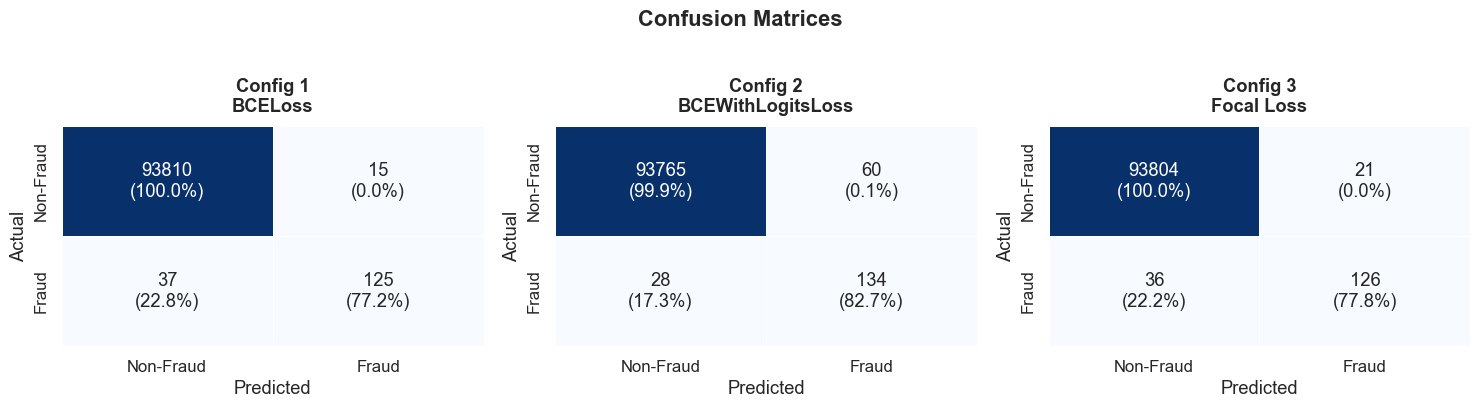

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
config_names = ['Config 1\nBCELoss', 'Config 2\nBCEWithLogitsLoss', 'Config 3\nFocal Loss']

for ax, name, metrics in zip(axes, config_names, [metrics1, metrics2, metrics3]):
    cm = metrics['confusion_matrix']
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([
        [f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
        for row_v, row_p in zip(cm, cm_pct)
    ])
    sns.heatmap(
        cm, annot=annot, fmt='', cmap='Blues', ax=ax,
        xticklabels=['Non-Fraud', 'Fraud'],
        yticklabels=['Non-Fraud', 'Fraud'],
        cbar=False, linewidths=0.5, linecolor='white'
    )
    ax.set_title(name, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
metrics_df = pd.DataFrame({
    'Config': ['Config 1\n(BCELoss)', 'Config 2\n(BCEWithLogitsLoss)', 'Config 3\n(Focal Loss)'] * 3,
    'Metric': ['Precision'] * 3 + ['Recall'] * 3 + ['F1 Score'] * 3,
    'Score': [
        metrics1['precision'], metrics2['precision'], metrics3['precision'],
        metrics1['recall'],    metrics2['recall'],    metrics3['recall'],
        metrics1['f1'],        metrics2['f1'],        metrics3['f1'],
    ]
})

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Config', y='Score', hue='Metric', palette='muted', ax=ax)

for container in ax.containers:
    if isinstance(container, BarContainer):
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

ax.set_ylim(0, 1.12)
ax.set_title('Precision, Recall and F1 Score by Configuration', fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.legend(title='', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

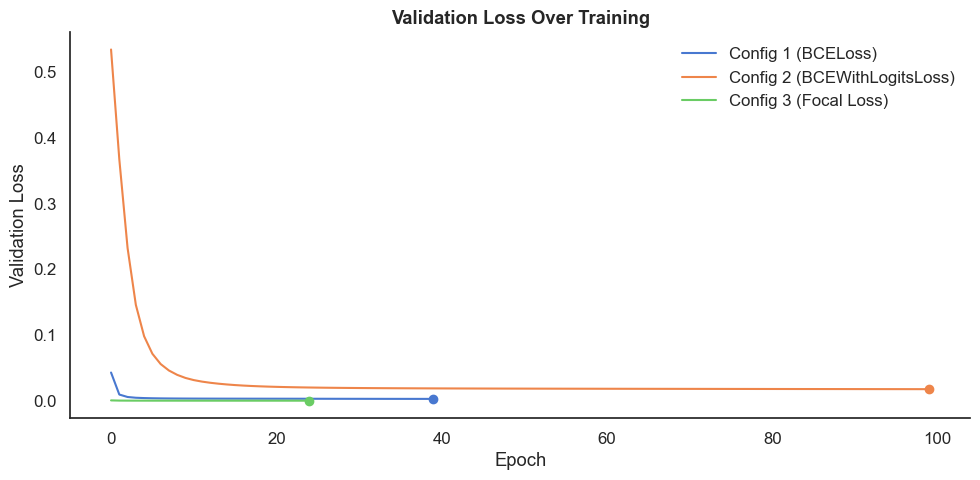

In [52]:
palette = sns.color_palette("muted")
fig, ax = plt.subplots(figsize=(10, 5))

for losses, label, color in [
    (losses1, 'Config 1 (BCELoss)', palette[0]),
    (losses2, 'Config 2 (BCEWithLogitsLoss)', palette[1]),
    (losses3, 'Config 3 (Focal Loss)', palette[2]),
]:
    epochs_range = range(len(losses))
    sns.lineplot(x=epochs_range, y=losses, label=label, color=color, ax=ax)
    ax.plot(len(losses) - 1, losses[-1], 'o', color=color, markersize=6, zorder=5)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss Over Training', fontweight='bold')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### Comparison with Similar Tutorials

This tutorial was developed with reference to the Kaggle tutorial by Rina Buoy [5], which also tackles credit card fraud detection using PyTorch and BCEWithLogitsLoss. The table below highlights the key differences in approach:

| Aspect | Kaggle Tutorial [5] | This Tutorial                                           |
|--------|---------------------|---------------------------------------------------------|
| Optimiser | SGD with momentum | Adam                                                    |
| Feature scaling | MinMaxScaler (all features) | StandardScaler (Amount only; V1–V28 pre-scaled via PCA) |
| Batch size | 100 | 4096                                                    |
| Training epochs | 200 | 40 (BCE), 100 (Weighted BCE), 25 (Focal Loss)           |
| Loss functions compared | 1 (BCEWithLogitsLoss) | 3 (BCE, BCEWithLogitsLoss, Focal Loss)                  |
| Architecture sweep | No | 16, 32, 64, 128 hidden nodes                      |
| GPU acceleration | No | CUDA and Apple MPS                                |
| Evaluation metrics | Accuracy, AUROC, AUPRC | Precision, Recall, F1, Confusion Matrix                 |

**Pros of the Kaggle tutorial:**
- Single configuration therefore simpler and more beginner friendly
- 200 training epochs allow fuller model convergence, reducing sensitivity to early stopping

**Cons of the Kaggle tutorial:**
- A single loss function with no comparative analysis means the reader cannot assess which approach is most suitable for their context
- Applies MinMaxScaler to all features, including V1–V28 which are already PCA-standardised; this unnecessarily distorts an already well-scaled feature space
- A batch size of 100 means most batches statistically contain no fraudulent transactions, making the gradient signal for the minority class very sparse during training
- No GPU support limits scalability to larger datasets

**What this tutorial adds:**
By comparing three distinct loss functions across four hidden layer sizes, this tutorial gives the reader a richer understanding of the design space for fraud detection models. The choice of Adam, a larger batch size, and selective scaling (Amount only) are deliberate decisions each justified in context. The systematic results table and visualisations make it straightforward to draw actionable conclusions — for example, that Config 2 may be preferable in contexts where minimising false negatives outweighs precision.

**Performance Comparison:**
The Kaggle tutorial achieves 82% recall with balanced 82% precision. Our Config 2 demonstrates a precision-recall tradeoff: achieving 83% recall (1% improvement) at the cost of reduced precision (71%). This illustrates how weighted BCE can be tuned to prioritise recall when business requirements dictate that missing fraud is more costly than investigating false alarms.

## References

[1] ULB Machine Learning Group. *Credit Card Fraud Detection*. Kaggle, 2018. Available at: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

[2] Real Python. *How to Use scikit-learn's train_test_split()*. Real Python. Available at: https://realpython.com/train-test-split-python-data/

[3] GeeksforGeeks. *Batch Size in Neural Network*. GeeksforGeeks. Available at: https://www.geeksforgeeks.org/deep-learning/batch-size-in-neural-network/

[4] PyTorch. *torch.utils.data*. PyTorch Documentation. Available at: https://docs.pytorch.org/docs/stable/data.html

[5] R. Buoy. *Credit Card Fraud Detection with PyTorch*. Kaggle. Available at: https://www.kaggle.com/code/rinabuoy/credit-card-fraud-detection-with-pytorch

[6] PyTorch. *Build the Neural Network*. PyTorch Tutorials. Available at: https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

[7] Labelf AI. *What is Accuracy, Precision, Recall and F1 Score?*. Labelf AI Blog. Available at: https://www.labelf.ai/blog/what-is-accuracy-precision-recall-and-f1-score

[8] PyTorch. *BCELoss*. PyTorch Documentation. Available at: https://docs.pytorch.org/docs/stable/generated/torch.nn.BCELoss.html

[9] D.P. Kingma and J. Ba. *Adam: A Method for Stochastic Optimization*. arXiv:1412.6980, 2014. Available at: https://arxiv.org/abs/1412.6980

[10] PyTorch. *BCEWithLogitsLoss*. PyTorch Documentation. Available at: https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.loss.BCEWithLogitsLoss.html

[11] T.Y. Lin, P. Goyal, R. Girshick, K. He, and P. Dollár. *Focal Loss for Dense Object Detection*. IEEE/CVF International Conference on Computer Vision (ICCV), 2017. Available at: https://arxiv.org/abs/1708.02002